In [191]:
import pandas as pd

import matplotlib.pyplot as plt

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for a cleaner look
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = [12, 6]

# No Baseline

In [192]:
vanilla_v3 = pd.read_csv("/home/jovyan/novitskiy/skoltech/lunarlander-rl/runs/reinforce_none_v3/metrics.csv")

Text(0, 0.5, 'Mean Return')

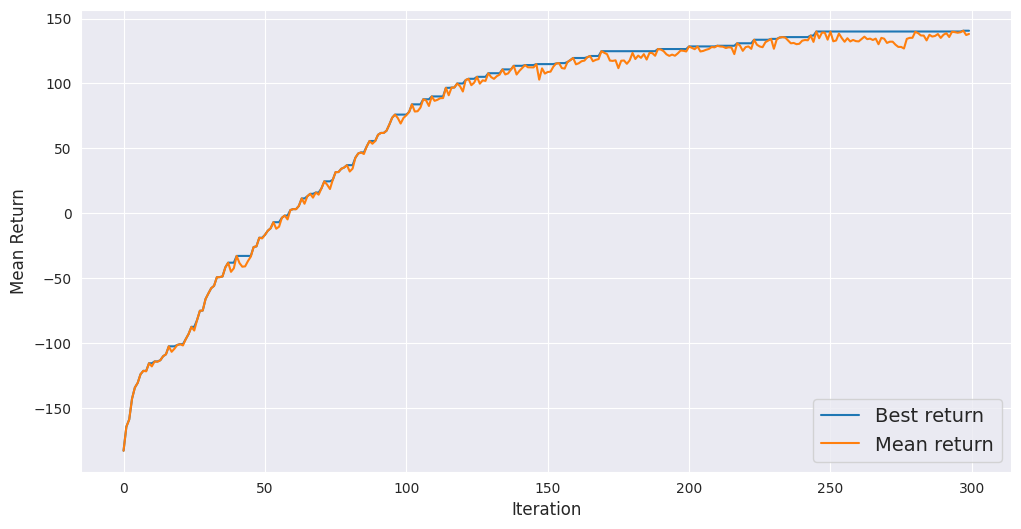

In [193]:
plt.plot(vanilla_v3.iteration, vanilla_v3.best_return, label='Best return')
plt.plot(vanilla_v3.iteration, vanilla_v3.mean_return, label='Mean return')
plt.legend(fontsize=14, loc='lower right')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Mean Return', fontsize=12)

# NN

In [194]:
nn_v3 = pd.read_csv("/home/jovyan/novitskiy/skoltech/lunarlander-rl/runs/reinforce_nn_v3/metrics.csv")

Text(0, 0.5, 'Mean Return')

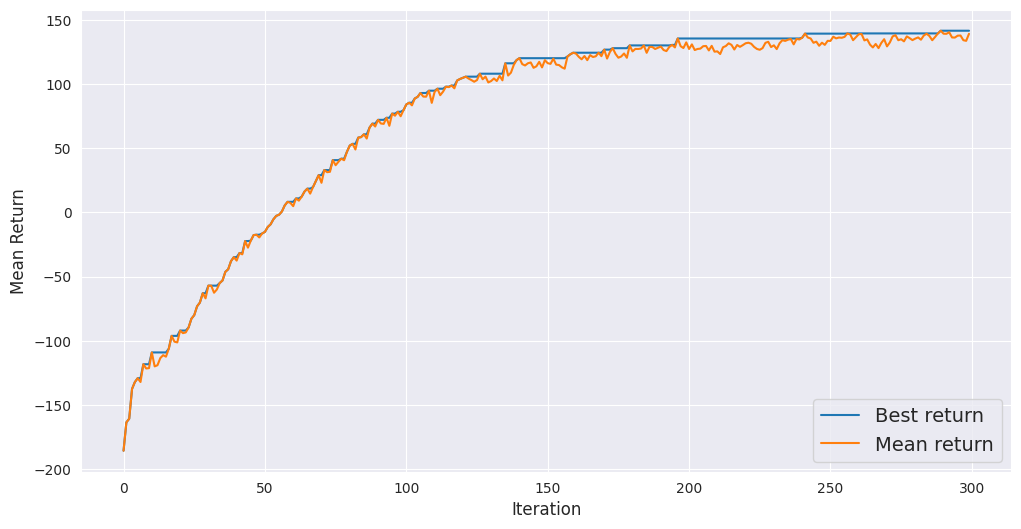

In [195]:
plt.plot(nn_v3.iteration, nn_v3.best_return, label='Best return')
plt.plot(nn_v3.iteration, nn_v3.mean_return, label='Mean return')
plt.legend(fontsize=14, loc='lower right')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Mean Return', fontsize=12)

# GAE

In [196]:
gae_no_nn_v3 = pd.read_csv("/home/jovyan/novitskiy/skoltech/lunarlander-rl/runs/reinforce_gae_no_nn_v2/metrics.csv")

Text(0, 0.5, 'Mean Return')

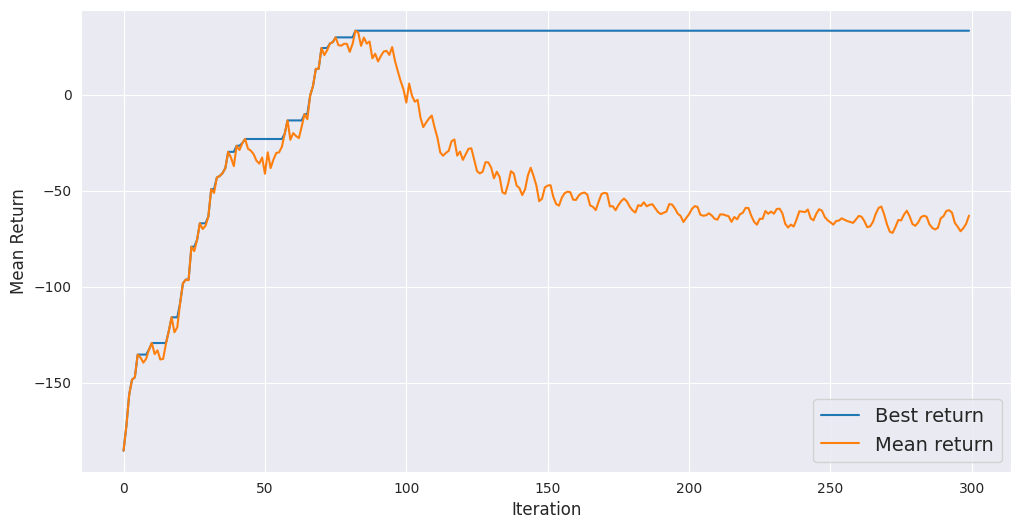

In [197]:
plt.plot(gae_no_nn_v3.iteration, gae_no_nn_v3.best_return, label='Best return')
plt.plot(gae_no_nn_v3.iteration, gae_no_nn_v3.mean_return, label='Mean return')
plt.legend(fontsize=14, loc='lower right')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Mean Return', fontsize=12)

# GAE NN

In [198]:
gae_nn_v3 = pd.read_csv("/home/jovyan/novitskiy/skoltech/lunarlander-rl/runs/reinforce_gae_nn_v2/metrics.csv")

Text(0, 0.5, 'Mean Return')

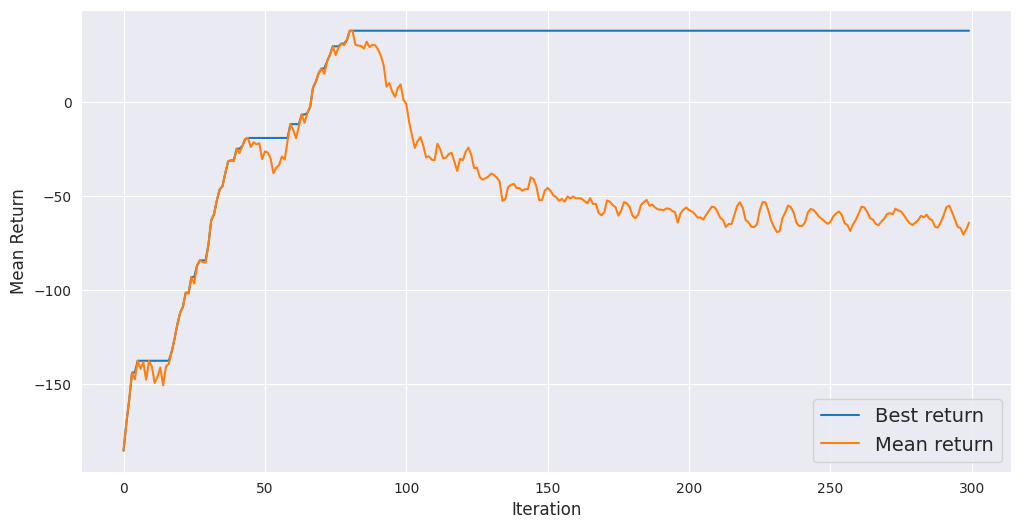

In [199]:
plt.plot(gae_nn_v3.iteration, gae_nn_v3.best_return, label='Best return')
plt.plot(gae_nn_v3.iteration, gae_nn_v3.mean_return, label='Mean return')
plt.legend(fontsize=14, loc='lower right')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Mean Return', fontsize=12)

# Viz

In [200]:
# !uv pip install seaborn

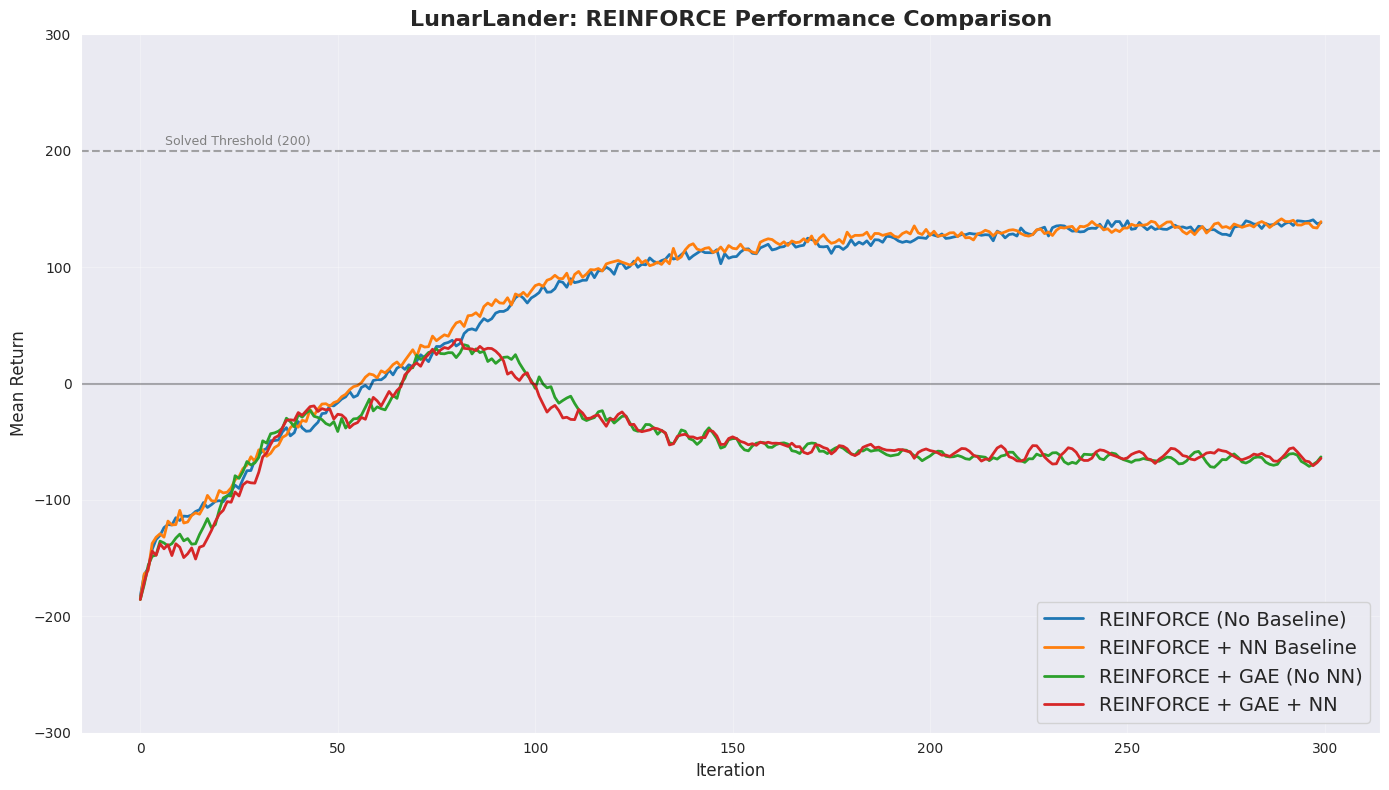

In [201]:
# Load your data
vanilla_v3 = pd.read_csv("/home/jovyan/novitskiy/skoltech/lunarlander-rl/runs/reinforce_none_v3/metrics.csv")
nn_v3 = pd.read_csv("/home/jovyan/novitskiy/skoltech/lunarlander-rl/runs/reinforce_nn_v3/metrics.csv")
gae_no_nn_v3 = pd.read_csv("/home/jovyan/novitskiy/skoltech/lunarlander-rl/runs/reinforce_gae_no_nn_v2/metrics.csv")
gae_nn_v3 = pd.read_csv("/home/jovyan/novitskiy/skoltech/lunarlander-rl/runs/reinforce_gae_nn_v2/metrics.csv")

# Create the plot
plt.figure(figsize=(14, 8))

# Plot each variant with different styles
plt.plot(vanilla_v3['iteration'], vanilla_v3['mean_return'], 
         label='REINFORCE (No Baseline)', linewidth=2, color='#1f77b4')
plt.plot(nn_v3['iteration'], nn_v3['mean_return'], 
         label='REINFORCE + NN Baseline', linewidth=2, color='#ff7f0e')
plt.plot(gae_no_nn_v3['iteration'], gae_no_nn_v3['mean_return'], 
         label='REINFORCE + GAE (No NN)', linewidth=2, color='#2ca02c')
plt.plot(gae_nn_v3['iteration'], gae_nn_v3['mean_return'], 
         label='REINFORCE + GAE + NN', linewidth=2, color='#d62728')

# Add labels and title
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Mean Return', fontsize=12)
plt.title('LunarLander: REINFORCE Performance Comparison', fontsize=16, fontweight='bold')

# Add legend
plt.legend(fontsize=14, loc='lower right')

# Add horizontal line at 200 (solving the environment)
plt.axhline(y=200, color='gray', linestyle='--', alpha=0.7, label='Solved (200)')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add some grid for better readability
plt.grid(True, alpha=0.3)

# Set y-axis limits to better see the progression
plt.ylim(-300, 300)

# Add text annotation for the solved threshold
plt.text(plt.xlim()[1]*0.02, 205, 'Solved Threshold (200)', fontsize=9, color='gray')

# Show the plot
plt.tight_layout()

plt.savefig("images/reinforce.png", bbox_inches='tight')

---
## PPO: KL effects

In [202]:
ppo_results = [
    "/home/jovyan/avarlamov/skoltech/lunarlander-rl/runs/ppo_exp_002_kl_0.0",
    "/home/jovyan/avarlamov/skoltech/lunarlander-rl/runs/ppo_exp_004_kl_0.01",
    "/home/jovyan/avarlamov/skoltech/lunarlander-rl/runs/ppo_exp_005_kl_0.2",
    "/home/jovyan/avarlamov/skoltech/lunarlander-rl/runs/ppo_exp_003_kl_0.1",
    "/home/jovyan/avarlamov/skoltech/lunarlander-rl/runs/ppo_exp_005_kl_0.5",
    "/home/jovyan/avarlamov/skoltech/lunarlander-rl/runs/ppo_exp_005_kl_0.7",
    "/home/jovyan/avarlamov/skoltech/lunarlander-rl/runs/ppo_exp_005_kl_1.0",
]

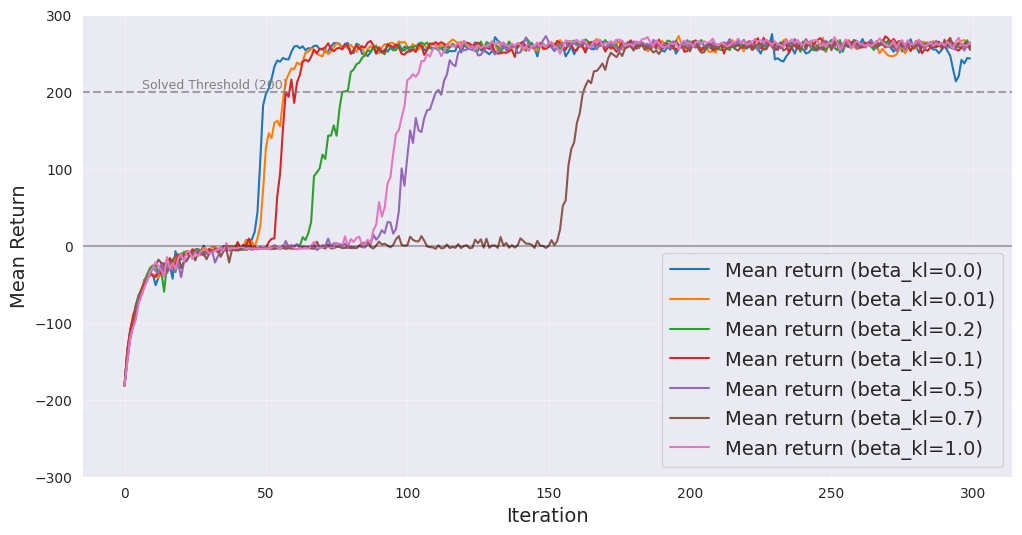

In [203]:
for folder in ppo_results:
    ppo = pd.read_csv(f"{folder}/metrics.csv")
    ppo = ppo.iloc[:301]
    kl = float(folder.split("kl_")[-1])
    # plt.plot(ppo.iteration, ppo.best_return, label=f'Best return (beta_kl={kl})')
    plt.plot(ppo.iteration, ppo.mean_return, label=f'Mean return (beta_kl={kl})')
plt.legend(fontsize=14, loc='lower right')

plt.xlabel('Iteration', fontsize=14)
plt.ylabel('Mean Return', fontsize=14)

# Add horizontal line at 200 (solving the environment)
plt.axhline(y=200, color='gray', linestyle='--', alpha=0.7, label='Solved (200)')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add some grid for better readability
plt.grid(True, alpha=0.3)

# Set y-axis limits to better see the progression
plt.ylim(-300, 300)

# Add text annotation for the solved threshold
plt.text(plt.xlim()[1]*0.02, 205, 'Solved Threshold (200)', fontsize=9, color='gray')

plt.savefig("images/ppo_kl.png", bbox_inches='tight')

## PPO: epsilon effects

In [204]:
ppo_results = [
    "/home/jovyan/avarlamov/skoltech/lunarlander-rl/runs/ppo_exp_006_clip_0.01_kl_0.5",
    "/home/jovyan/avarlamov/skoltech/lunarlander-rl/runs/ppo_exp_006_clip_0.05_kl_0.5",
    "/home/jovyan/avarlamov/skoltech/lunarlander-rl/runs/ppo_exp_005_clip_0.1_kl_0.5",
    "/home/jovyan/avarlamov/skoltech/lunarlander-rl/runs/ppo_exp_006_clip_0.2_kl_0.5",
    "/home/jovyan/avarlamov/skoltech/lunarlander-rl/runs/ppo_exp_006_clip_0.5_kl_0.5"
]

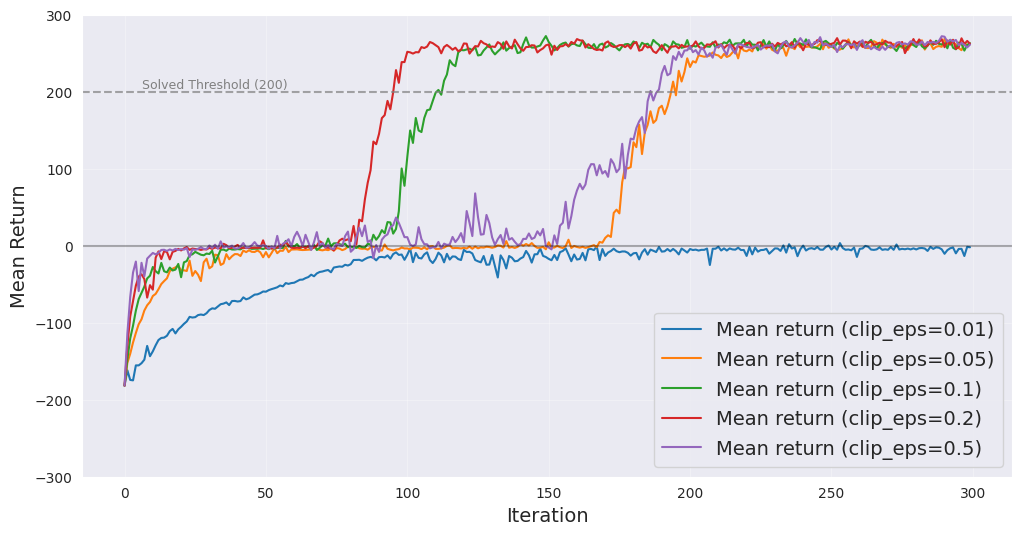

In [205]:
for folder in ppo_results:
    ppo = pd.read_csv(f"{folder}/metrics.csv")
    ppo = ppo.iloc[:301]
    clip_eps = float(float(folder.split("clip_")[-1].split("_kl_")[0]))
    # plt.plot(ppo.iteration, ppo.best_return, label=f'Best return (beta_kl={kl})')
    plt.plot(ppo.iteration, ppo.mean_return, label=f'Mean return (clip_eps={clip_eps})')
plt.legend(fontsize=14, loc='lower right')

plt.xlabel('Iteration', fontsize=14)
plt.ylabel('Mean Return', fontsize=14)

# Add horizontal line at 200 (solving the environment)
plt.axhline(y=200, color='gray', linestyle='--', alpha=0.7, label='Solved (200)')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add some grid for better readability
plt.grid(True, alpha=0.3)

# Set y-axis limits to better see the progression
plt.ylim(-300, 300)

# Add text annotation for the solved threshold
plt.text(plt.xlim()[1]*0.02, 205, 'Solved Threshold (200)', fontsize=9, color='gray')

plt.savefig("images/ppo_clip_eps.png", bbox_inches='tight')

## GRPO

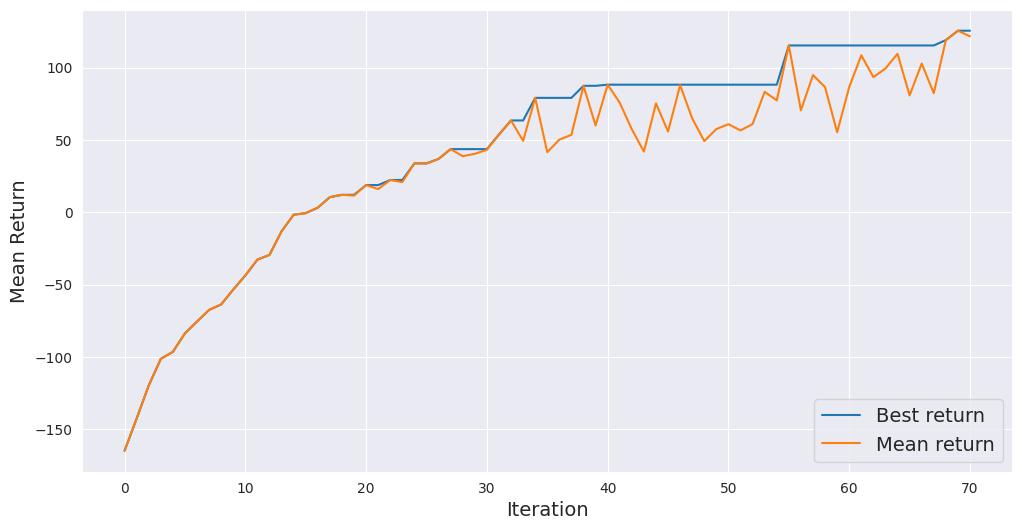

In [ ]:
grpo = pd.read_csv("/home/jovyan/avarlamov/skoltech/lunarlander-rl/runs/grpo_fixed_groups/metrics.csv")
grpo = grpo.iloc[:301]

ppo = pd.read_csv("/home/jovyan/avarlamov/skoltech/lunarlander-rl/runs/ppo_exp_005_kl_0.5")
ppo = ppo.iloc[:301]

plt.plot(grpo.iteration, grpo.best_return, label=f'Best return')
plt.plot(grpo.iteration, grpo.mean_return, label=f'Mean return')
plt.legend(fontsize=14, loc='lower right')

plt.xlabel('Iteration', fontsize=14)
plt.ylabel('Mean Return', fontsize=14)

plt.savefig("images/grpo.png", bbox_inches='tight')

## PPO with wind:

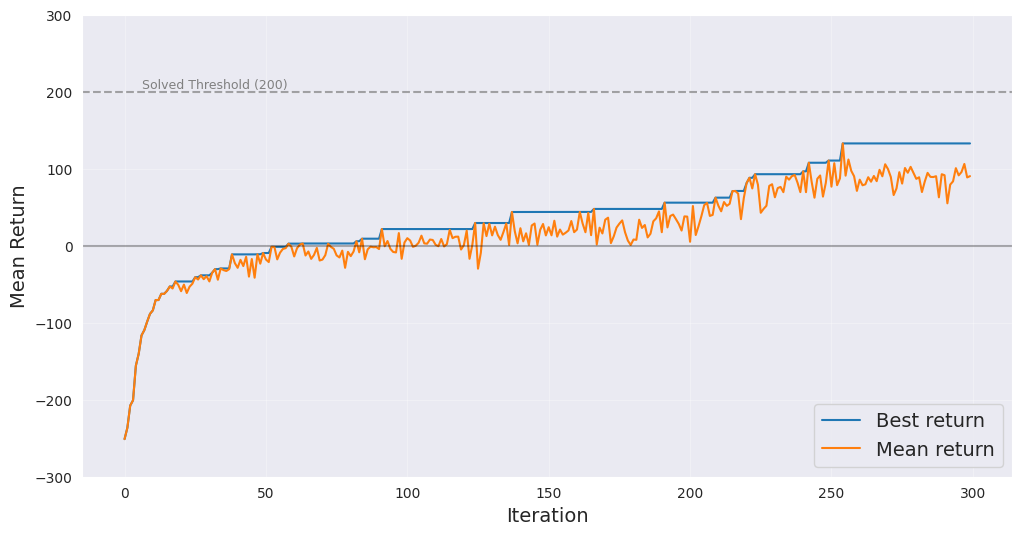

In [207]:
ppo_wind = pd.read_csv("/home/jovyan/avarlamov/skoltech/lunarlander-rl/runs/ppo_wind/metrics.csv")
ppo_wind = ppo_wind.iloc[:301]


plt.plot(ppo_wind.iteration, ppo_wind.best_return, label=f'Best return')
plt.plot(ppo_wind.iteration, ppo_wind.mean_return, label=f'Mean return')
plt.legend(fontsize=14, loc='lower right')

plt.xlabel('Iteration', fontsize=14)
plt.ylabel('Mean Return', fontsize=14)

# Add horizontal line at 200 (solving the environment)
plt.axhline(y=200, color='gray', linestyle='--', alpha=0.7, label='Solved (200)')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add some grid for better readability
plt.grid(True, alpha=0.3)

# Set y-axis limits to better see the progression
plt.ylim(-300, 300)

# Add text annotation for the solved threshold
plt.text(plt.xlim()[1]*0.02, 205, 'Solved Threshold (200)', fontsize=9, color='gray')

plt.savefig("images/ppo_wind.png", bbox_inches='tight')